  迈克尔逊干涉仪 — 最小二乘法数据分析

拟合直线: d = 52.836904 + 0.00031625·N
斜率 b = 0.00031625 mm/条纹
波长 λ = 2b = 632.5 nm
决定系数 R^2 = 0.999198

各组 Δd → 波长:
  Δd(1) = 0.01484 mm  →  λ = 593.6 nm
  Δd(2) = 0.01585 mm  →  λ = 634.0 nm
  Δd(3) = 0.01517 mm  →  λ = 606.8 nm
  Δd(4) = 0.01815 mm  →  λ = 726.0 nm
  Δd(5) = 0.01414 mm  →  λ = 565.6 nm

与 He-Ne 标准波长 632.8 nm 的相对误差: 0.05%

图片已保存: 迈克尔逊干涉仪_数据分析.png


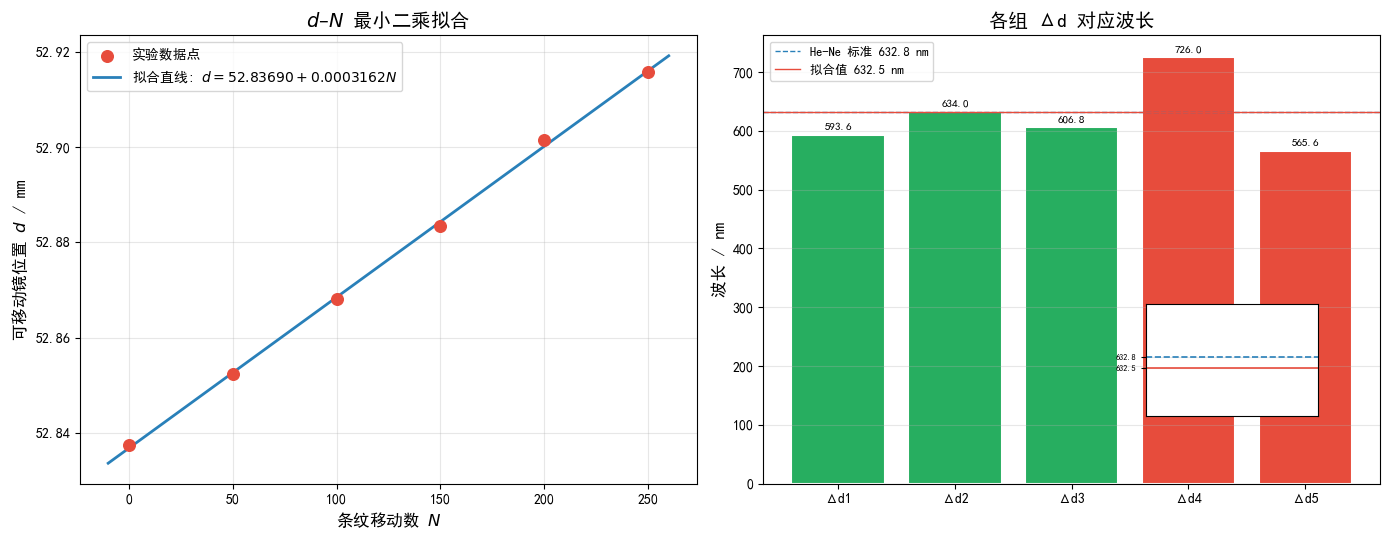

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 数据
# ============================================================
N = np.array([0, 50, 100, 150, 200, 250])
d = np.array([52.83751, 52.85235, 52.86820, 52.88337, 52.90152, 52.91566])

# ============================================================
# 最小二乘线性拟合: d = a + b * N
# ============================================================
n = len(N)
b = (n * np.sum(N * d) - np.sum(N) * np.sum(d)) / (n * np.sum(N**2) - np.sum(N)**2)
a = np.mean(d) - b * np.mean(N)

d_pred = a + b * N
ss_res = np.sum((d - d_pred)**2)
ss_tot = np.sum((d - np.mean(d))**2)
r2 = 1 - ss_res / ss_tot

lambda_nm = 2 * b * 1e6  # mm -> nm

# 各组 Δd 计算的波长
delta_d = np.diff(d)
lambda_individual = 2 * delta_d / 50 * 1e6  # nm

# ============================================================
# 打印结果
# ============================================================
print("=" * 55)
print("  迈克尔逊干涉仪 — 最小二乘法数据分析")
print("=" * 55)
print(f"\n拟合直线: d = {a:.6f} + {b:.8f}·N")
print(f"斜率 b = {b:.8f} mm/条纹")
print(f"波长 λ = 2b = {lambda_nm:.1f} nm")
print(f"决定系数 R^2 = {r2:.6f}")
print(f"\n各组 Δd → 波长:")
for i in range(len(delta_d)):
    print(f"  Δd({i+1}) = {delta_d[i]:.5f} mm  →  λ = {lambda_individual[i]:.1f} nm")
print(f"\n与 He-Ne 标准波长 632.8 nm 的相对误差: "
      f"{abs(lambda_nm - 632.8) / 632.8 * 100:.2f}%")

# ============================================================
# 可视化
# ============================================================
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# ---- 左图: d-N 散点 + 拟合直线 ----
ax1.scatter(N, d, c="#E74C3C", s=70, zorder=5, label="实验数据点")
N_fit = np.linspace(-10, 260, 100)
ax1.plot(N_fit, a + b * N_fit, "#2980B9", linewidth=2,
         label=f"拟合直线: $d = {a:.5f} + {b:.7f}N$")
ax1.set_xlabel("条纹移动数 $N$", fontsize=12)
ax1.set_ylabel("可移动镜位置 $d$ / mm", fontsize=12)
ax1.set_title("$d$–$N$ 最小二乘拟合", fontsize=14)
ax1.legend(fontsize=10, loc="upper left")
ax1.grid(True, alpha=0.3)



# ---- 右图: 各组波长柱状图 ----
x_pos = np.arange(len(lambda_individual))
colors = ["#E74C3C" if abs(lam - 632.8) > 50 else "#27AE60"
          for lam in lambda_individual]
ax2.bar(x_pos, lambda_individual, color=colors, edgecolor="white", linewidth=1.5)
ax2.axhline(y=632.8, color="#2980B9", linestyle="--", linewidth=1,
            label="He-Ne 标准 632.8 nm")
ax2.axhline(y=lambda_nm, color="#E74C3C", linestyle="-", linewidth=1,
            label=f"拟合值 {lambda_nm:.1f} nm")
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f"Δd{i+1}" for i in range(len(delta_d))])
ax2.set_ylabel("波长 / nm", fontsize=12)
ax2.set_title("各组 Δd 对应波长", fontsize=14)
ax2.legend(fontsize=9, loc="upper left")
ax2.grid(True, alpha=0.3, axis="y")

# 在柱状图上标数值
for i, (lam, dd) in enumerate(zip(lambda_individual, delta_d)):
    ax2.text(i, lam + 8, f"{lam:.1f}", ha="center", fontsize=8)

# ---- 局部放大图（右下角，紧凑） ----
axins = ax2.inset_axes([0.62, 0.15, 0.28, 0.25])
axins.set_ylim(631.2, 634.2)
axins.set_xlim(-0.2, 4.2)
axins.axhline(y=632.8, color="#2980B9", linestyle="--", linewidth=1.2)
axins.axhline(y=lambda_nm, color="#E74C3C", linestyle="-", linewidth=1.2)
axins.set_xticks([])
axins.set_yticks([632.8, lambda_nm])
axins.set_yticklabels([f"632.8", f"{lambda_nm:.1f}"], fontsize=6)
axins.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("迈克尔逊干涉仪_数据分析.png", dpi=200, bbox_inches="tight")
print(f"\n图片已保存: 迈克尔逊干涉仪_数据分析.png")
plt.show()